In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
ssp3 = pd.read_excel('ojode.xlsx', sheet_name='SSP3')
ssp4 = pd.read_excel('ojode.xlsx', sheet_name='SSP4')


In [24]:
# Lets check for the missing values for each. We start with SSP3
ssp3.isnull().sum()

code        0
name        0
2010-07    19
2015-07    20
2020-07    21
2025-07    21
2030-07    22
2035-07    21
2040-07    22
2045-07    22
2050-07    21
2055-07    20
2060-07    20
2065-07    18
2070-07    17
2075-07    15
2080-07    15
2085-07    14
2090-07    14
2095-07    15
2100-07    17
dtype: int64

In [25]:
# We can't drop the missing values, lets interpolate
# Interpolate missing values for each
year_cols = [col for col in ssp3.columns if col not in ['code', 'name']]

# Step 1 - fill gaps in the middle
ssp3[year_cols] = ssp3[year_cols].interpolate(axis=1)

# Step 2 - fill gaps at the start (forward fill)
ssp3[year_cols] = ssp3[year_cols].ffill(axis=1)

# Step 3 - fill gaps at the end (backward fill)
ssp3[year_cols] = ssp3[year_cols].bfill(axis=1)


In [26]:
ssp3.isnull().sum()

code        0
name        0
2010-07    10
2015-07    10
2020-07    10
2025-07    10
2030-07    10
2035-07    10
2040-07    10
2045-07    10
2050-07    10
2055-07    10
2060-07    10
2065-07    10
2070-07    10
2075-07    10
2080-07    10
2085-07    10
2090-07    10
2095-07    10
2100-07    10
dtype: int64

In [27]:
# Find rows where ALL year values are missing
empty_rows = ssp3[ssp3[year_cols].isnull().all(axis=1)]
print(empty_rows[['code', 'name']])

    code         name
8    AUT      Austria
11   BEL      Belgium
29   CHE  Switzerland
45   DNK      Denmark
54   FIN      Finland
78   ISL      Iceland
98   LUX   Luxembourg
123  NOR       Norway
154  SVN     Slovenia
155  SWE       Sweden


In [28]:
ssp3 = ssp3.dropna(subset=year_cols, how='all')

In [29]:
ssp3.isnull().sum()

code       0
name       0
2010-07    0
2015-07    0
2020-07    0
2025-07    0
2030-07    0
2035-07    0
2040-07    0
2045-07    0
2050-07    0
2055-07    0
2060-07    0
2065-07    0
2070-07    0
2075-07    0
2080-07    0
2085-07    0
2090-07    0
2095-07    0
2100-07    0
dtype: int64

In [30]:
# Now lets do for SSP4
ssp4.isnull().sum()

code         0
name         0
2010-07     63
2015-07     65
2020-07     70
2025-07     76
2030-07     79
2035-07     83
2040-07     86
2045-07     88
2050-07     96
2055-07     97
2060-07     98
2065-07    101
2070-07    107
2075-07    109
2080-07    110
2085-07    111
2090-07    114
2095-07    116
2100-07    118
dtype: int64

In [31]:
# We can't drop the missing values, lets interpolate
# Interpolate missing values for each
year_cols = [col for col in ssp3.columns if col not in ['code', 'name']]

ssp4[year_cols] = ssp4[year_cols].interpolate(axis=1)
ssp4[year_cols] = ssp4[year_cols].ffill(axis=1)
ssp4[year_cols] = ssp4[year_cols].bfill(axis=1)


In [32]:
ssp4.isnull().sum()

code        0
name        0
2010-07    62
2015-07    62
2020-07    62
2025-07    62
2030-07    62
2035-07    62
2040-07    62
2045-07    62
2050-07    62
2055-07    62
2060-07    62
2065-07    62
2070-07    62
2075-07    62
2080-07    62
2085-07    62
2090-07    62
2095-07    62
2100-07    62
dtype: int64

In [33]:
empty_rows = ssp4[ssp4[year_cols].isnull().all(axis=1)]
print(empty_rows[['code', 'name']])

    code                              name
3    ALB                           Albania
4    ARE              United Arab Emirates
5    ARG                         Argentina
6    ARM                           Armenia
7    AUS                         Australia
..   ...                               ...
167  TUR                           Türkiye
168  TWN                               TWN
171  UKR                           Ukraine
175  VCT  Saint Vincent and the Grenadines
179  WSM                             Samoa

[62 rows x 2 columns]


In [34]:
# Lets define EA
east_africa = ['Kenya', 'Tanzania', 'Uganda', 'Rwanda', 'Burundi']

In [35]:
# Now lets filter east_africa from the original dataset
ssp3_ea = ssp3[ssp3['name'].isin(east_africa)]
ssp4_ea = ssp4[ssp4['name'].isin(east_africa)]


In [36]:
# Now we add a scenario column and call it ssp3 and 4 respectively
ssp3_ea ['scenario'] = 'SSP3'
ssp4_ea['scenario'] = 'SSP4'

In [37]:
# Lets combine these datasets
ea_pov = pd.concat([ssp3_ea, ssp4_ea], ignore_index=True)

In [38]:
ea_pov.info

<bound method DataFrame.info of   code      name     2010-07     2015-07     2020-07     2025-07     2030-07  \
0  BDI   Burundi   7325353.0   8005612.0   8178915.0   8056980.0   7628627.0   
1  KEN     Kenya  19525472.0  20018568.0  19777772.0  19507824.0  19444900.0   
2  RWA    Rwanda   6588251.0   6698997.0   6691586.0   6606745.0   6595055.0   
3  TZA  Tanzania  23017246.0  22200260.0  20340668.0  18286824.0  16683745.0   
4  UGA    Uganda  19192324.0  20537756.0  20738268.0  20950736.0  21481304.0   
5  BDI   Burundi        77.0        73.0        66.0        59.0        52.0   
6  KEN     Kenya       228.0       206.0       183.0       163.0       149.0   
7  RWA    Rwanda        49.0        44.0        39.0        35.0        32.0   
8  TZA  Tanzania        55.0        45.0        37.0        30.0        25.0   
9  UGA    Uganda        62.0        55.0        48.0        42.0        38.0   

      2035-07     2040-07     2045-07  ...     2060-07     2065-07  \
0   7096206.0   6

In [39]:
print(ea_pov)


  code      name     2010-07     2015-07     2020-07     2025-07     2030-07  \
0  BDI   Burundi   7325353.0   8005612.0   8178915.0   8056980.0   7628627.0   
1  KEN     Kenya  19525472.0  20018568.0  19777772.0  19507824.0  19444900.0   
2  RWA    Rwanda   6588251.0   6698997.0   6691586.0   6606745.0   6595055.0   
3  TZA  Tanzania  23017246.0  22200260.0  20340668.0  18286824.0  16683745.0   
4  UGA    Uganda  19192324.0  20537756.0  20738268.0  20950736.0  21481304.0   
5  BDI   Burundi        77.0        73.0        66.0        59.0        52.0   
6  KEN     Kenya       228.0       206.0       183.0       163.0       149.0   
7  RWA    Rwanda        49.0        44.0        39.0        35.0        32.0   
8  TZA  Tanzania        55.0        45.0        37.0        30.0        25.0   
9  UGA    Uganda        62.0        55.0        48.0        42.0        38.0   

      2035-07     2040-07     2045-07  ...     2060-07     2065-07  \
0   7096206.0   6411738.0   5675136.0  ...   3353

In [40]:
ea_pov.isnull().sum()

code        0
name        0
2010-07     0
2015-07     0
2020-07     0
2025-07     0
2030-07     0
2035-07     0
2040-07     0
2045-07     0
2050-07     0
2055-07     0
2060-07     0
2065-07     0
2070-07     0
2075-07     0
2080-07     0
2085-07     0
2090-07     0
2095-07     0
2100-07     0
scenario    0
dtype: int64

In [41]:
# Reshape from wide to long format
ea_pov_long = ea_pov.melt(
    id_vars=['code', 'name', 'scenario'],
    var_name='year',
    value_name='poverty'
)

# Clean the year column
ea_pov_long['year'] = ea_pov_long['year'].str.replace('-07', '').astype(int)

print(ea_pov_long.head())

  code      name scenario  year     poverty
0  BDI   Burundi     SSP3  2010   7325353.0
1  KEN     Kenya     SSP3  2010  19525472.0
2  RWA    Rwanda     SSP3  2010   6588251.0
3  TZA  Tanzania     SSP3  2010  23017246.0
4  UGA    Uganda     SSP3  2010  19192324.0


In [42]:
ea_pov_long.info

<bound method DataFrame.info of     code      name scenario  year     poverty
0    BDI   Burundi     SSP3  2010   7325353.0
1    KEN     Kenya     SSP3  2010  19525472.0
2    RWA    Rwanda     SSP3  2010   6588251.0
3    TZA  Tanzania     SSP3  2010  23017246.0
4    UGA    Uganda     SSP3  2010  19192324.0
..   ...       ...      ...   ...         ...
185  BDI   Burundi     SSP4  2100         1.0
186  KEN     Kenya     SSP4  2100        47.0
187  RWA    Rwanda     SSP4  2100        12.0
188  TZA  Tanzania     SSP4  2100         1.0
189  UGA    Uganda     SSP4  2100         6.0

[190 rows x 5 columns]>

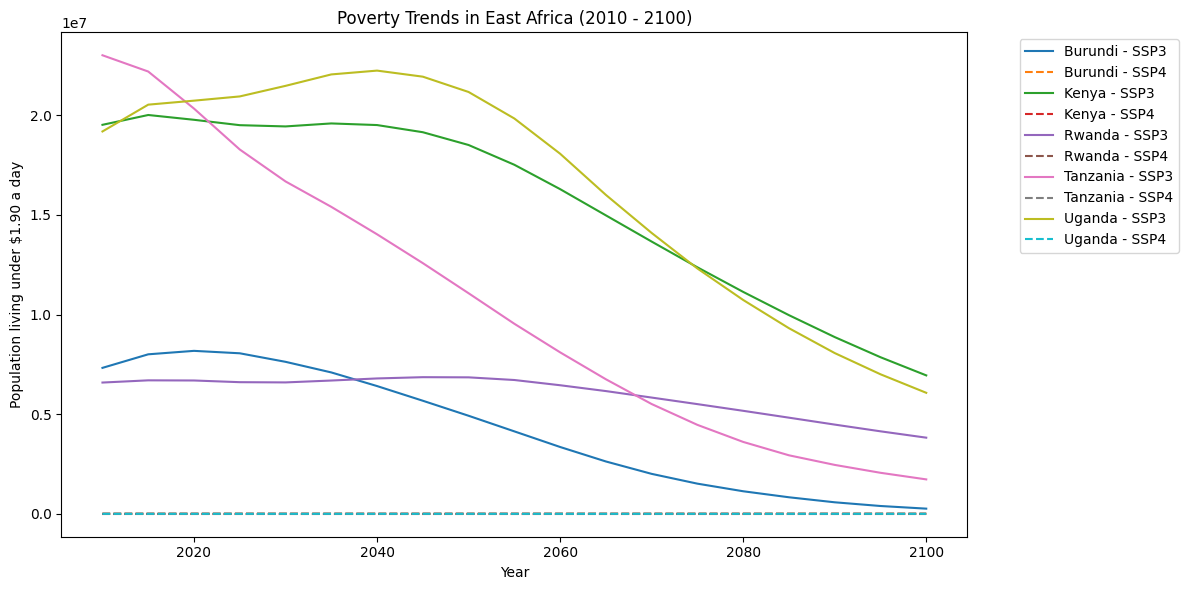

In [43]:
# lets check poverty trends in East Afric 2010-2100 with SSP3 and SSP4

fig, ax =plt.subplots(figsize=(12,6))

for country in ea_pov_long['name'].unique():
    for scenario in ['SSP3', 'SSP4']:
        data = ea_pov_long[(ea_pov_long['name']== country) & (ea_pov_long['scenario'] == scenario)]
        ax.plot(
            data['year'],
            data['poverty'],
            label=f"{country} - {scenario}",
            linestyle = '--' if scenario == 'SSP4' else '-'
        )
ax.set_title('Poverty Trends in East Africa (2010 - 2100)')
ax.set_xlabel('Year')
ax.set_ylabel('Population living under $1.90 a day')
ax.legend(bbox_to_anchor =(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

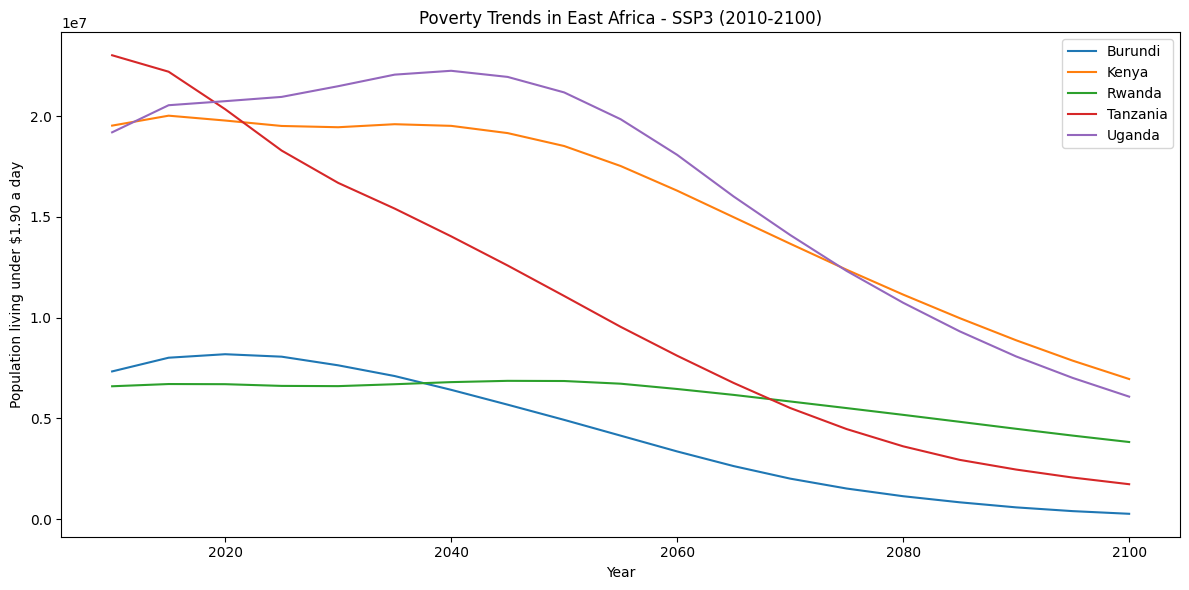

In [47]:
# Lets do for SSP3 only
# Filter SSP3 only
ssp3_long = ea_pov_long[ea_pov_long['scenario'] == 'SSP3']

fig, ax = plt.subplots(figsize=(12, 6))

for country in ssp3_long['name'].unique():
    data = ssp3_long[ssp3_long['name'] == country]
    ax.plot(data['year'], data['poverty'], label=country)

ax.set_title('Poverty Trends in East Africa - SSP3 (2010-2100)')
ax.set_xlabel('Year')
ax.set_ylabel('Population living under $1.90 a day')
ax.legend()
plt.tight_layout()
plt.show()

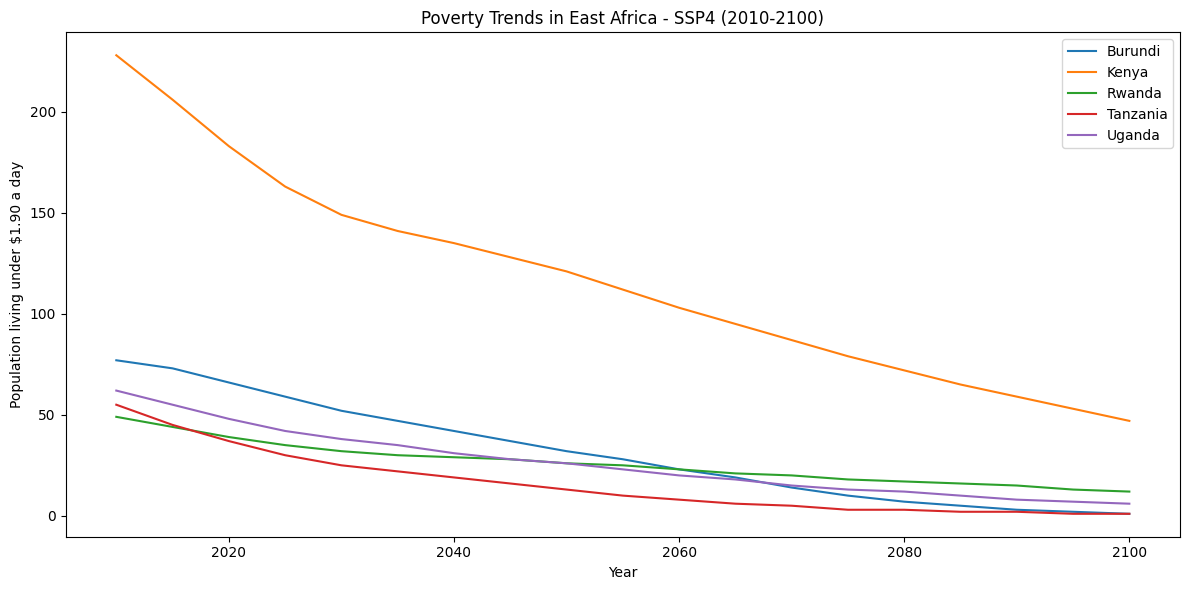

In [50]:
# For SSP4
# Filter SSP4 only
ssp4_long = ea_pov_long[ea_pov_long['scenario'] == 'SSP4']

fig, ax = plt.subplots(figsize=(12, 6))

for country in ssp4_long['name'].unique():
    data = ssp4_long[ssp4_long['name'] == country]
    ax.plot(data['year'], data['poverty'], label=country)

ax.set_title('Poverty Trends in East Africa - SSP4 (2010-2100)')
ax.set_xlabel('Year')
ax.set_ylabel('Population living under $1.90 a day')
ax.legend()
plt.tight_layout()
plt.show()